t-SNE

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

In [ ]:

digits=load_digits()
X,y=digits.data, digits.target  #X contiene le feature, y contiene le etichette, cioè il numero scritto nell'immagine
#nel dataset digits ogni riga è un'immagine 8X8 pixel (8X8=64)
print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


STANDARIZZO i valori di tutte le feature

(porto ogni colonna a media=0 deviazione_standard=1)
per rendere le feature confrontabili tra loro
Nel dataset digits tutte le 64 feature sono pixel, pertanto hanno già la stessa scala (da 0 a 16), quidni la standarizzazione non sarebbe obbligatoria come in altri dataset

In [ ]:
scaler=StandardScaler()
X_std=scaler.fit_transform(X)
#X_std=X #se non voglio standarizzare ma lasciare la sezione per altri esempi

RIDUZIONE DIMENSIONALE

Riduco il dataset a 2 feature con la PCA
ottengo PCA1 e PCA2

In [ ]:
pca_2=PCA(n_components=2)
X_pca2=pca_2.fit_transform(X_std)
print(X_pca2.shape)
print(f"Varianza spiegata dalle 2 feature ottenute con PCA: {pca_2.explained_variance_ratio_.sum()}") 

(1797, 2)
Varianza spiegata dalle 2 feature ottenute con PCA: 0.2850936482369929


varianza spiegata da PCA 2 dimensioni 28.51% un po' bassa

Riduco il dataset a 30 feature (da 64 iniziali), con metodo lineare
successivamente applico la t-SNE, con metodo non linare
per arrivare a 2 features (n_components=2), per una visualizzazione, 2D, più semplice da capire

In [ ]:
#Riduzione dimensionale a 30 (da 64 originali) con PCA
pca_30=PCA(n_components=30)
X_pca30=pca_30.fit_transform(X_std)
print(X_pca30.shape)
print(f"Varianza spiegata dalle 30 feature ottenute con PCA: {pca_30.explained_variance_ratio_.sum()}\n") 
#applico t-SNE su riduzione dimensionale a 30 e riduco ulteriormente a 2 dimensioni
tsne=TSNE(n_components=2,perplexity=30,learning_rate=200,max_iter=1_000,init="pca",random_state=42,verbose=1)
X_tsne=tsne.fit_transform(X_pca30)
print(X_tsne.shape)

(1797, 30)
Varianza spiegata dalle 30 feature ottenute con PCA: 0.959085404245717

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.001s...
[t-SNE] Computed neighbors for 1797 samples in 0.055s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 11.223570
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.246773
[t-SNE] KL divergence after 1000 iterations: 0.732401
(1797, 2)


Varianza spiegata con PCA su 30 dimensioni 95.91% molto buono

CATEGORIZZO

Applico il k_Means

1) applico il k-means sulle coordinate PCA a 2 dimensioni
2) applico il k-means sulle coordinate PCA a 30 dimensioni
3) applico il k-means sulle coordinate t-sne a 2 dimensioni (normalmente questa soluzione non è da adottare perchè applico il k-means, cioè la categorizzazione, su un algoritmo che non preserva la geometria globale del dataset originale, come appunto ta t-SNE)

Poi qui decido quello migliore

In [44]:
#1) k-means sulle cordinate PCA a 2 dimensioni
kmeans_pca2 = KMeans(n_clusters=10, random_state=42,n_init=20)
labels_kmeans_pca2 = kmeans_pca2.fit_predict(X_pca2)

#2)Faccio clustering sulle componenti pca a 30 dimensioni, usero' il t_SNE solo per il grafico
kmeans_pca30 = KMeans(n_clusters=10, random_state=42,n_init=20)
labels_kmeans_pca30 = kmeans_pca30.fit_predict(X_pca30)

#3) k-means sulle cordinate t-SNE a 2 dimensioni
kmeans_tsne = KMeans(n_clusters=10, random_state=42,n_init=20)
labels_kmeans_tsne = kmeans_tsne.fit_predict(X_tsne)


In [48]:
print("Inertia PCA2:", kmeans_pca2.inertia_)
print("Inertia PCA30:", kmeans_pca30.inertia_)
print("Inertia tSNE:", kmeans_tsne.inertia_)

Inertia PCA2: 56220.172267134214
Inertia PCA30: 1077870.367896778
Inertia tSNE: 111824.8125


Visualizzo gli score per le 3 soluzioni
e decido di scartare il pca30 a favore del tsne (ha uno score migliore)
Questo risultato è anomalo, normalmente il kmean non si applica ad un tsne ma in questo caso a pca 30

In [45]:
from sklearn.metrics import adjusted_rand_score

print(f"ARI pca 2 dimensioni:{adjusted_rand_score(y, labels_kmeans_pca2)}")
print(f"ARI pca t-SNE 2 dimensioni:{adjusted_rand_score(y, labels_kmeans_tsne)}")
print(f"ARI pca 30 dimensioni:{adjusted_rand_score(y, labels_kmeans_pca30)}")

ARI pca 2 dimensioni:0.393597016138886
ARI pca t-SNE 2 dimensioni:0.885665377507163
ARI pca 30 dimensioni:0.6684559990956909


Plotting
1) Dataset con PCA (p=2) con le vere etichette
2) Dataset con t-SNE (p=30) con le vere etichette
3) Clustering con KMeans sul dataset ridotto con PCA (p=2)
4) Clustering con KMeans sul dastaset ridotto con t-SNE (p=30)

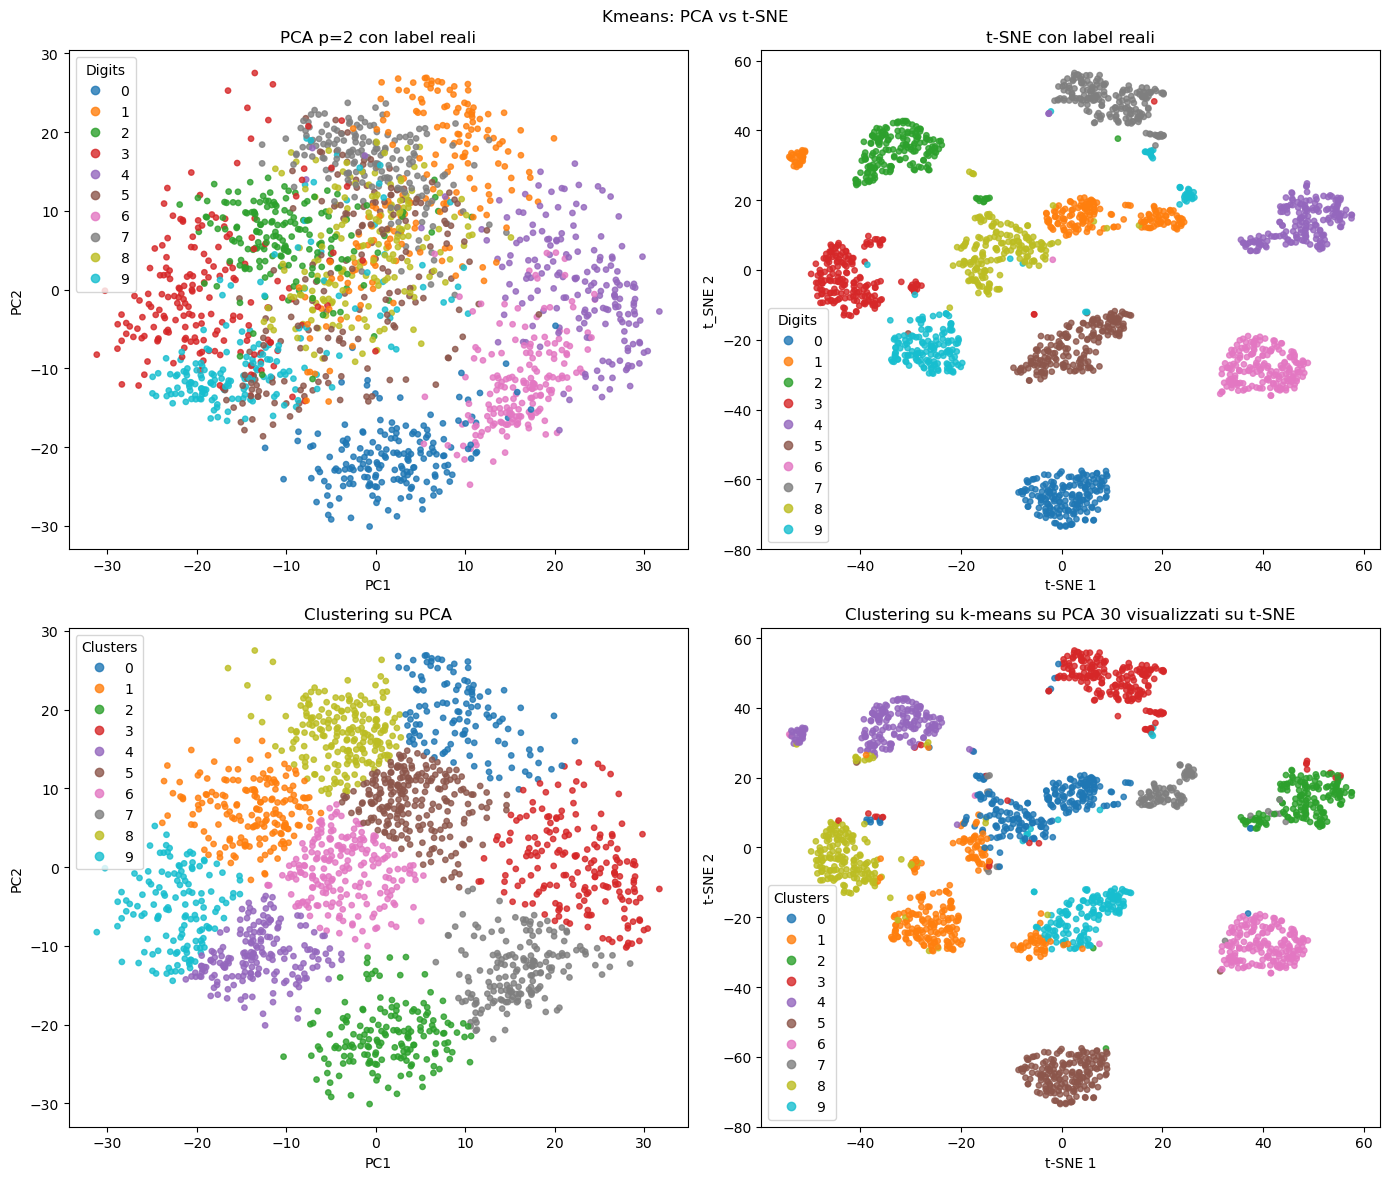

In [47]:
fig, axes =plt.subplots(2,2,figsize=(14,12))
fig.suptitle("Kmeans: PCA vs t-SNE")

ax=axes[0,0]
scatter=ax.scatter(X_pca2[:,0],X_pca2[:,1],c=y,cmap="tab10",s=15,alpha=0.8)
ax.set_title("PCA p=2 con label reali")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(*scatter.legend_elements(), title="Digits",loc="best")

ax=axes[0,1]
scatter=ax.scatter(X_tsne[:,0],X_tsne[:,1],c=y,cmap="tab10",s=15,alpha=0.8)
ax.set_title("t-SNE con label reali")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t_SNE 2")
ax.legend(*scatter.legend_elements(), title="Digits",loc="best")

ax=axes[1,0]
scatter=ax.scatter(X_pca2[:,0],X_pca2[:,1],c=labels_kmeans_pca2,cmap="tab10",s=15,alpha=0.8)
ax.set_title("Clustering su PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(*scatter.legend_elements(), title="Clusters",loc="best")

ax=axes[1,1]
scatter=ax.scatter(X_tsne[:,0],X_tsne[:,1],c=labels_kmeans_pca30,cmap="tab10",s=15,alpha=0.8)
ax.set_title("Clustering su k-means su PCA 30 visualizzati su t-SNE")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(*scatter.legend_elements(), title="Clusters",loc="best")

plt.tight_layout()
plt.show()
